# RACE-V4 — Risk-Aware Conditional Multimodal Escalation

This notebook is the **V4 research revision** of the CFUR multimodal fake-news
detection pipeline.

## Scientific question

> Under a fixed additional-compute budget, can a calibrated multimodal risk
> estimator identify samples for which the cheap prediction is most likely to
> be wrong, so that expensive ViLT reasoning is invoked only when it is needed?

### Why V4 replaces counterfactual-utility prediction

The V3 experiment showed that direct counterfactual-utility ranking did not
remain competitive after cross-fitting. V4 therefore tests a narrower and
more robust hypothesis: **risk-aware selective escalation**.

### V4 design

1. Frozen CLIP and ViLT backbones.
2. A cheap multimodal classifier and a residual ViLT correction head.
3. A leakage-safe risk split that is never used to train the cheap/deep heads.
4. A calibrated logistic risk estimator predicting `P(cheap prediction is wrong)`.
5. Matched-budget routing at 0–100% deep execution.
6. Strong uncertainty, modality-disagreement, and random baselines.
7. An analysis-only Oracle upper bound.
8. Risk-ranking, bootstrap, and resource/latency analyses.

The goal is not to force a positive result. The decision gate at the end of
the notebook determines whether RACE-V4 is strong enough for a multi-seed
paper experiment.


In [1]:
# Kaggle dependency setup
# Internet must be enabled for the first model download.
#
# Pillow ships quarterly and has twice broken this exact import chain:
#   ImportError: cannot import name '_Ink' from 'PIL._typing'
# 12.0.0/12.1.0 shipped the bug outright; 12.2.0 fixed it; 12.3.0 (2026-07-01)
# reworked ImageText/ImageFont interop and appears to have reintroduced it.
# Pin to the known-good window instead of an open-ended ">=".
#
# pip installing a newer Pillow inside a cell does not retroactively fix a
# module that's already loaded in the running kernel, so this cell installs
# once, then force-restarts the kernel so the next pass actually picks it up.
import os

_FLAG = "/kaggle/working/.cfur_v2_deps_installed"

if not os.path.exists(_FLAG):
    get_ipython().system('pip -q install -U "transformers>=5.0,<6" accelerate safetensors scikit-learn pandas "pillow>=12.2.0,<12.3.0" tqdm psutil requests')
    with open(_FLAG, "w") as f:
        f.write("ok")
    print("Dependencies installed with a safe Pillow pin. Restarting the kernel now \u2014 "
          "re-run this cell (or Run All) once more to continue.")
    os.kill(os.getpid(), 9)
else:
    print("Dependencies already installed in this session \u2014 continuing.")


Dependencies already installed in this session — continuing.


In [2]:
import os, gc, time, math, random, warnings, json, subprocess, sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import CLIPModel, CLIPProcessor, ViltModel, ViltProcessor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    log_loss, roc_auc_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
# ============================================================
# V4 CONFIGURATION
# ============================================================

RUN_MODE = "PILOT"       # "PILOT" or "PAPER"
TASKS_TO_RUN = ["binary"]  # ["binary"] or ["binary", "six_way"]

if RUN_MODE == "PAPER":
    SEEDS = [13, 37, 71, 101, 202]
    MAX_TRAIN, MAX_VAL, MAX_TEST = None, None, None
else:
    SEEDS = [13]
    MAX_TRAIN, MAX_VAL, MAX_TEST = 12000, 2000, 2000

# Change to "6_way_label" for the fine-grained task.
FAKEDDIT_LABEL_COL = "2_way_label"

MANIFEST_CSV = ""

TEXT_COL_CANDIDATES = ["clean_title", "title", "text"]
ID_COL_CANDIDATES = ["id", "submission_id"]
FAKEDDIT_IMAGE_URL_CANDIDATES = ["image_url", "img_url"]

CLIP_NAME = "openai/clip-vit-base-patch32"
VILT_NAME = "dandelin/vilt-b32-mlm"

BATCH_CLIP = 32
BATCH_VILT = 16
HEAD_BATCH = 512

HEAD_EPOCHS = 20 if RUN_MODE == "PAPER" else 12
ROUTER_EPOCHS = 25 if RUN_MODE == "PAPER" else 12
PATIENCE = 4

LR_HEAD = 1e-3
LR_ROUTER = 8e-4
WEIGHT_DECAY = 1e-4

# Keep classifier training and router target estimation separated.
ROUTER_HOLDOUT = 0.20

# V4: the router predicts the probability that the cheap decision is wrong.
# The router never sees labels from the base split used to train the cheap/deep models.
RISK_ROUTER_C = 0.10
RISK_ROUTER_MAX_ITER = 1500
RISK_CALIBRATION_C = 1.0

# Representative fractions used for risk-ranking diagnostics.
RISK_TOPK_FRACTIONS = [0.01, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00]

# The core contribution is evaluated at all these budgets.
BUDGETS = [0.00, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

N_BOOT = 1000 if RUN_MODE == "PAPER" else 300

ALLOW_IMAGE_URL_FALLBACK = True
IMAGE_DOWNLOAD_WORKERS = 24
IMAGE_DOWNLOAD_TIMEOUT = 8
IMAGE_DOWNLOAD_DIRNAME = "fakeddit_images_v4"

OUT_DIR = Path("/kaggle/working/cfur_v4_outputs")
CACHE_DIR = Path("/kaggle/working/cfur_v4_cache")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEEDS[0])
print("RUN_MODE:", RUN_MODE)
print("Seeds:", SEEDS)
print("Task:", FAKEDDIT_LABEL_COL)
print("Budgets:", BUDGETS)

RUN_MODE: PILOT
Seeds: [13]
Task: 2_way_label
Budgets: [0.0, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]


## Data loading

The previous Kaggle run had no local image files and recovered only the rows whose historical image URLs were still reachable. V2 keeps that behavior but makes the availability statistics explicit.

For a manuscript run, **prefer a Kaggle dataset containing local Fakeddit images** and set `MANIFEST_CSV` to a manifest with:

`text,image_path,label,split`

That avoids URL survivorship bias.

In [4]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"None of {candidates} found. Available columns: {list(df.columns)[:50]}"
    )

def build_image_index(root="/kaggle/input"):
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    index = {}
    for p in tqdm(Path(root).rglob("*"), desc="indexing local images"):
        if p.is_file() and p.suffix.lower() in exts:
            index.setdefault(p.stem, str(p))
    print("Local images indexed:", len(index))
    return index

def pick_fakeddit_files():
    files = list(Path("/kaggle/input").rglob("*.tsv"))
    def choose(words):
        cands = []
        for p in files:
            s = p.name.lower()
            if "multimodal" in s and any(w in s for w in words):
                cands.append(p)
        return sorted(cands, key=lambda x: len(str(x)))[0] if cands else None
    return (
        choose(["train"]),
        choose(["validate", "validation", "val"]),
        choose(["test_public", "test"])
    )

def stratified_cap(df, n, label_col, seed):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    try:
        _, sampled = train_test_split(
            df, test_size=n, stratify=df[label_col], random_state=seed
        )
        return sampled.reset_index(drop=True)
    except Exception:
        return df.sample(n=n, random_state=seed).reset_index(drop=True)

def download_images_from_urls(
    df, url_col, id_col, out_dir,
    workers=24, timeout=8
):
    import requests
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    def fetch(sid, url):
        sid = str(sid)
        if not isinstance(url, str) or not url.startswith("http"):
            return sid, None
        dest = out_dir / f"{sid}.jpg"
        if dest.exists() and dest.stat().st_size > 0:
            return sid, str(dest)
        try:
            r = requests.get(
                url,
                timeout=timeout,
                headers={"User-Agent": "Mozilla/5.0"}
            )
            if r.status_code == 200 and r.content:
                with open(dest, "wb") as f:
                    f.write(r.content)
                return sid, str(dest)
        except Exception:
            pass
        return sid, None

    pairs = list(zip(df[id_col].astype(str), df[url_col]))
    result = {}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(fetch, sid, url) for sid, url in pairs]
        for fut in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="downloading images"
        ):
            sid, path = fut.result()
            if path:
                result[sid] = path
    return result

def standardize_fakeddit(df, split_name, image_index):
    text_col = first_existing_col(df, TEXT_COL_CANDIDATES)
    id_col = first_existing_col(df, ID_COL_CANDIDATES)
    if FAKEDDIT_LABEL_COL not in df.columns:
        raise ValueError(
            f"{FAKEDDIT_LABEL_COL} not found. "
            f"Label columns: {[c for c in df.columns if 'label' in c.lower()]}"
        )
    out = pd.DataFrame({
        "text": df[text_col].fillna("").astype(str),
        "sample_id": df[id_col].astype(str),
        "label": df[FAKEDDIT_LABEL_COL],
        "split": split_name
    })
    out["image_path"] = out["sample_id"].map(image_index)
    before = len(out)
    out = out.dropna(subset=["image_path", "label"])
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    print(f"{split_name}: {len(out)}/{before} rows have usable text+image")
    return out[["text", "image_path", "label", "split", "sample_id"]]

def load_manifest():
    if MANIFEST_CSV:
        m = pd.read_csv(MANIFEST_CSV)
        required = {"text", "image_path", "label", "split"}
        missing = required - set(m.columns)
        if missing:
            raise ValueError(f"Manifest missing columns: {missing}")
        return m

    train_p, val_p, test_p = pick_fakeddit_files()
    print("Detected:", train_p, val_p, test_p)
    if not all([train_p, val_p, test_p]):
        raise FileNotFoundError(
            "Could not find Fakeddit multimodal TSVs. "
            "Attach the Fakeddit dataset or set MANIFEST_CSV."
        )

    raw = {
        "train": pd.read_csv(train_p, sep="\t"),
        "val": pd.read_csv(val_p, sep="\t"),
        "test": pd.read_csv(test_p, sep="\t")
    }

    image_index = build_image_index("/kaggle/input")

    if len(image_index) == 0 and ALLOW_IMAGE_URL_FALLBACK:
        print("No local images found. Downloading only bounded pilot/full-mode rows.")
        url_col = first_existing_col(raw["train"], FAKEDDIT_IMAGE_URL_CANDIDATES)
        id_col = first_existing_col(raw["train"], ID_COL_CANDIDATES)

        caps = {
            "train": MAX_TRAIN,
            "val": MAX_VAL,
            "test": MAX_TEST
        }

        for split in ["train", "val", "test"]:
            cap = caps[split]
            if cap is None:
                cap = 50000
            # Oversample candidates to compensate for dead historical URLs.
            candidate_n = min(
                len(raw[split]),
                int(cap * 1.5) if cap else len(raw[split])
            )
            raw[split] = stratified_cap(
                raw[split], candidate_n, FAKEDDIT_LABEL_COL, SEEDS[0]
            )

        download_dir = CACHE_DIR / IMAGE_DOWNLOAD_DIRNAME
        image_index = {}
        for split in ["train", "val", "test"]:
            got = download_images_from_urls(
                raw[split],
                url_col,
                id_col,
                download_dir,
                workers=IMAGE_DOWNLOAD_WORKERS,
                timeout=IMAGE_DOWNLOAD_TIMEOUT
            )
            image_index.update(got)

        print("Total downloaded/cached images:", len(image_index))

    return pd.concat([
        standardize_fakeddit(raw["train"], "train", image_index),
        standardize_fakeddit(raw["val"], "val", image_index),
        standardize_fakeddit(raw["test"], "test", image_index)
    ], ignore_index=True)

manifest = load_manifest()
print("Rows after availability filtering:", len(manifest))
display(manifest.groupby("split").size().rename("available_rows").to_frame())

Detected: /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_validate.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_test_public.tsv


indexing local images: 0it [00:00, ?it/s]

Local images indexed: 0
No local images found. Downloading only bounded pilot/full-mode rows.


downloading images:   0%|          | 0/18000 [00:00<?, ?it/s]

downloading images:   0%|          | 0/3000 [00:00<?, ?it/s]

downloading images:   0%|          | 0/3000 [00:00<?, ?it/s]

Total downloaded/cached images: 22719
train: 17016/18000 rows have usable text+image
val: 2857/3000 rows have usable text+image
test: 2846/3000 rows have usable text+image
Rows after availability filtering: 22719


,available_rows
split,
test,2846
train,17016
val,2857


In [5]:
le = LabelEncoder()
manifest["label_raw"] = manifest["label"]
manifest["label"] = le.fit_transform(manifest["label"].astype(str))
NUM_CLASSES = len(le.classes_)

train_df = stratified_cap(
    manifest[manifest.split=="train"].copy(),
    MAX_TRAIN, "label", SEEDS[0]
)
val_df = stratified_cap(
    manifest[manifest.split=="val"].copy(),
    MAX_VAL, "label", SEEDS[0]
)
test_df = stratified_cap(
    manifest[manifest.split=="test"].copy(),
    MAX_TEST, "label", SEEDS[0]
)

print("Classes:", dict(enumerate(le.classes_)))
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
print("Train class distribution:")
display(train_df["label"].value_counts(normalize=True).sort_index())

Classes: {0: '0', 1: '1'}
Train/Val/Test: 12000 2000 2000
Train class distribution:


label
0    0.617583
1    0.382417
Name: proportion, dtype: float64

In [6]:
class RawMultimodalDataset(Dataset):
    def __init__(self, frame):
        self.df = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row.image_path).convert("RGB")
            w, h = img.size
            if w < 2 or h < 2 or max(w,h)/max(min(w,h),1) > 20:
                img = Image.new("RGB", (224,224), "white")
        except Exception:
            img = Image.new("RGB", (224,224), "white")
        return {
            "text": str(row.text),
            "image": img,
            "label": int(row.label),
            "row_id": i
        }

def raw_collate(batch):
    return {
        "texts": [x["text"] for x in batch],
        "images": [x["image"] for x in batch],
        "labels": torch.tensor([x["label"] for x in batch], dtype=torch.long),
        "row_ids": np.array([x["row_id"] for x in batch], dtype=np.int64)
    }

datasets = {
    "train": RawMultimodalDataset(train_df),
    "val": RawMultimodalDataset(val_df),
    "test": RawMultimodalDataset(test_df)
}

## Frozen encoders

The backbones remain frozen for feasibility and to make the routing contribution identifiable.

In [7]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False

vilt_processor = ViltProcessor.from_pretrained(VILT_NAME)
vilt_model = ViltModel.from_pretrained(VILT_NAME).to(DEVICE).eval()
for p in vilt_model.parameters():
    p.requires_grad = False

CLIP_DIM = clip_model.config.projection_dim
VILT_DIM = vilt_model.config.hidden_size
print("CLIP_DIM =", CLIP_DIM, "VILT_DIM =", VILT_DIM)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                          | Status     |  | 
---------------------------------------------+------------+--+-
mlm_score.transform.dense.weight             | UNEXPECTED |  | 
mlm_score.transform.dense.bias               | UNEXPECTED |  | 
vilt.embeddings.text_embeddings.position_ids | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.weight         | UNEXPECTED |  | 
mlm_score.decoder.weight                     | UNEXPECTED |  | 
mlm_score.bias                               | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

CLIP_DIM = 512 VILT_DIM = 768


In [8]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def cache_ok(cache, n):
    if not cache.exists():
        return None
    z = np.load(cache)
    out = {k: z[k] for k in z.files}
    if len(out.get("row_id", [])) != n:
        print("Ignoring stale cache:", cache.name)
        return None
    return out

def extract_clip(ds, split):
    cache = CACHE_DIR / f"{split}_clip.npz"
    old = cache_ok(cache, len(ds))
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_CLIP, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    T,V,Y,IDS = [],[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"CLIP {split}"):
            proc = clip_processor(
                text=b["texts"], images=b["images"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=77
            )
            proc = {k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                te = clip_model.get_text_features(
                    input_ids=proc["input_ids"],
                    attention_mask=proc.get("attention_mask")
                )
                ie = clip_model.get_image_features(
                    pixel_values=proc["pixel_values"]
                )
            te = te.pooler_output if hasattr(te,"pooler_output") else te
            ie = ie.pooler_output if hasattr(ie,"pooler_output") else ie
            T.append(F.normalize(te.float(),dim=-1).cpu().numpy())
            V.append(F.normalize(ie.float(),dim=-1).cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "text":np.concatenate(T),
        "image":np.concatenate(V),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak])
    }
    np.savez_compressed(cache,**out)
    return out

def extract_vilt(ds, split):
    cache = CACHE_DIR / f"{split}_vilt.npz"
    old = cache_ok(cache, len(ds))
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_VILT, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    J,Y,IDS=[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"ViLT {split}"):
            proc=vilt_processor(
                images=b["images"], text=b["texts"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=40
            )
            proc={k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                out=vilt_model(**proc)
                joint=(
                    out.pooler_output
                    if getattr(out,"pooler_output",None) is not None
                    else out.last_hidden_state[:,0]
                )
            J.append(joint.float().cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "joint":np.concatenate(J),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak])
    }
    np.savez_compressed(cache,**out)
    return out

features={}
for split in ["train","val","test"]:
    features[(split,"clip")]=extract_clip(datasets[split],split)
    features[(split,"vilt")]=extract_vilt(datasets[split],split)

resource_rows=[]
for split in ["train","val","test"]:
    n=len(datasets[split])
    for comp,key in [("CLIP","clip"),("ViLT","vilt")]:
        f=features[(split,key)]
        resource_rows.append({
            "split":split,
            "component":comp,
            "n":n,
            "seconds":float(f["seconds"][0]),
            "ms_per_sample":1000*float(f["seconds"][0])/n,
            "peak_vram_mb":float(f["peak_mb"][0])
        })
resource_components=pd.DataFrame(resource_rows)
display(resource_components)
resource_components.to_csv(OUT_DIR/"resource_components.csv",index=False)

CLIP train:   0%|          | 0/375 [00:00<?, ?it/s]

ViLT train:   0%|          | 0/750 [00:00<?, ?it/s]

CLIP val:   0%|          | 0/63 [00:00<?, ?it/s]

ViLT val:   0%|          | 0/125 [00:00<?, ?it/s]

CLIP test:   0%|          | 0/63 [00:00<?, ?it/s]

ViLT test:   0%|          | 0/125 [00:00<?, ?it/s]

,split,component,n,seconds,ms_per_sample,peak_vram_mb
0,train,CLIP,12000,158.108528,13.175711,1081.951172
1,train,ViLT,12000,278.642746,23.220229,1340.735840
2,val,CLIP,2000,24.968042,12.484021,1081.951172
3,val,ViLT,2000,46.151960,23.075980,1339.657715
4,test,CLIP,2000,23.533186,11.766593,1081.952148
5,test,ViLT,2000,42.280710,21.140355,1328.489258


## Model heads

The expensive model is now a **residual deep head**:

`deep_logits = cheap_logits + learned correction(ViLT, text, image, cheap prediction)`

This asks the deep branch to spend its capacity on correcting the cheap decision rather than relearning the entire classifier from scratch.

Text-only and image-only heads provide the modality-disagreement baseline.

In [9]:
def cheap_features(t,v):
    cos=(t*v).sum(1,keepdims=True)
    return np.concatenate([t,v,np.abs(t-v),t*v,cos],1).astype("float32")

def modality_features(x):
    return np.asarray(x,dtype="float32")

def torchify(x):
    return torch.as_tensor(x,dtype=torch.float32)

class MLPHead(nn.Module):
    def __init__(self,in_dim,n_classes,hidden=256):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(hidden,128),
            nn.GELU(),
            nn.Dropout(.15),
            nn.Linear(128,n_classes)
        )
    def forward(self,x): return self.net(x)

class DeepResidualHead(nn.Module):
    def __init__(self,clip_dim,vilt_dim,n_classes,d=256):
        super().__init__()
        self.pt=nn.Linear(clip_dim,d)
        self.pv=nn.Linear(clip_dim,d)
        self.pj=nn.Linear(vilt_dim,d)
        self.fuse=nn.Sequential(
            nn.Linear(d*5+n_classes,512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(.25),
            nn.Linear(128 if False else 512,n_classes)
        )
    def forward(self,t,v,j,cheap_logits):
        t1=self.pt(t)
        v1=self.pv(v)
        j1=self.pj(j)
        z=torch.cat(
            [t1,v1,j1,torch.abs(t1-v1),t1*v1,cheap_logits],
            dim=1
        )
        # input is 5*d + n_classes
        return cheap_logits + self.fuse(z)

class UtilityRouter(nn.Module):
    def __init__(self,in_dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(256,64),
            nn.GELU(),
            nn.Linear(64,1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

In [10]:
def class_weights(y):
    classes=np.arange(NUM_CLASSES)
    try:
        w=compute_class_weight("balanced",classes=classes,y=y)
    except Exception:
        w=np.ones(NUM_CLASSES)
    return torch.tensor(w,dtype=torch.float32,device=DEVICE)

def predict_head(model,X,batch=2048):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(X),batch):
            out.append(model(torchify(X[i:i+batch]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

def train_mlp(model,Xtr,ytr,Xv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torch.tensor(ytr,dtype=torch.long)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def train_regressor(model,Xtr,ytr,Xv,yv,seed):
    # Dedicated trainer for scalar-regression heads (e.g. UtilityRouter),
    # as distinct from train_mlp above which is classification-only
    # (CrossEntropyLoss + long class labels + F1-based early stopping).
    # Uses LR_ROUTER/ROUTER_EPOCHS, which the config already defines
    # separately from LR_HEAD/HEAD_EPOCHS for exactly this purpose.
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_ROUTER,weight_decay=WEIGHT_DECAY)
    crit=nn.MSELoss()
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torchify(ytr)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=np.inf; state=None; wait=0
    for ep in range(ROUTER_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv)
        score=float(np.mean((pred-yv)**2))
        if score<best-1e-6:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def predict_deep(model,t,v,j,cheap_logits,batch=1024):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(t),batch):
            out.append(
                model(
                    torchify(t[i:i+batch]).to(DEVICE),
                    torchify(v[i:i+batch]).to(DEVICE),
                    torchify(j[i:i+batch]).to(DEVICE),
                    torchify(cheap_logits[i:i+batch]).to(DEVICE)
                ).cpu().numpy()
            )
    return np.concatenate(out)

def train_deep(model,ttr,vtr,jtr,ctr,ytr,tv,vv,jv,cv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    ds=TensorDataset(
        torchify(ttr),torchify(vtr),torchify(jtr),
        torchify(ctr),torch.tensor(ytr,dtype=torch.long)
    )
    loader=DataLoader(ds,batch_size=HEAD_BATCH,shuffle=True)
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for t,v,j,c,y in loader:
            t,v,j,c,y=t.to(DEVICE),v.to(DEVICE),j.to(DEVICE),c.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(t,v,j,c),y)
            loss.backward(); opt.step()
        pred=predict_deep(model,tv,vv,jv,cv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def softmax_np(logits):
    x=logits-logits.max(1,keepdims=True)
    e=np.exp(x)
    return e/e.sum(1,keepdims=True)

def per_sample_ce(logits,y):
    p=np.clip(softmax_np(logits),1e-9,1)
    return -np.log(p[np.arange(len(y)),y])

def entropy_np(p):
    p=np.clip(p,1e-9,1)
    return -(p*np.log(p)).sum(1,keepdims=True)

def modality_disagreement(text_logits,image_logits):
    pt=softmax_np(text_logits)
    pi=softmax_np(image_logits)
    return np.mean(np.abs(pt-pi),axis=1)

def router_features(t,v,cheap_logits,text_logits,image_logits):
    p=softmax_np(cheap_logits)
    maxp=p.max(1,keepdims=True)
    ent=entropy_np(p)
    if p.shape[1]>1:
        top=np.sort(p,axis=1)
        margin=(top[:,-1]-top[:,-2])[:,None]
    else:
        margin=maxp
    cos=(t*v).sum(1,keepdims=True)
    dis=modality_disagreement(text_logits,image_logits)[:,None]
    return np.concatenate(
        [t,v,np.abs(t-v),t*v,cos,ent,maxp,margin,dis],
        axis=1
    ).astype("float32")

def risk_feature_matrix(t,v,cheap_logits,text_logits,image_logits,base_X=None):
    """Compact, leakage-safe features for predicting cheap-model error risk."""
    p=softmax_np(cheap_logits)
    pt=softmax_np(text_logits)
    pi=softmax_np(image_logits)

    ent=entropy_np(p)
    maxp=p.max(1,keepdims=True)
    if p.shape[1]>1:
        s=np.sort(p,axis=1)
        margin=(s[:,-1]-s[:,-2])[:,None]
    else:
        margin=maxp

    text_max=pt.max(1,keepdims=True)
    image_max=pi.max(1,keepdims=True)
    text_ent=entropy_np(pt)
    image_ent=entropy_np(pi)

    cheap_pred=p.argmax(1)
    text_pred=pt.argmax(1)
    image_pred=pi.argmax(1)

    cos=(t*v).sum(1,keepdims=True)
    l1=np.mean(np.abs(t-v),axis=1,keepdims=True)
    l2=np.sqrt(np.mean((t-v)**2,axis=1,keepdims=True)+1e-8)

    dis=np.mean(np.abs(pt-pi),axis=1,keepdims=True)
    label_dis=(cheap_pred!=text_pred).astype("float32")[:,None]
    label_dis2=(cheap_pred!=image_pred).astype("float32")[:,None]
    modality_dis=(text_pred!=image_pred).astype("float32")[:,None]

    # A simple support/OOD proxy: average standardized deviation in cheap
    # feature space, using statistics estimated only from the base training set.
    if base_X is not None:
        mu=base_X.mean(0,keepdims=True)
        sd=base_X.std(0,keepdims=True)+1e-4
        support=np.mean(np.abs((cheap_features(t,v)-mu)/sd),axis=1,keepdims=True)
    else:
        support=np.zeros((len(t),1),dtype="float32")

    feats=np.concatenate([
        ent,maxp,margin,text_ent,text_max,image_ent,image_max,
        cos,l1,l2,dis,label_dis,label_dis2,modality_dis,support
    ],axis=1)
    return feats.astype("float32")

def fit_risk_model(X_fit,y_fit,X_cal,y_cal,seed):
    """
    Two-stage calibrated risk estimator.
    Stage 1: standardized logistic regression on out-of-sample router data.
    Stage 2: Platt calibration on a disjoint calibration subset.
    """
    seed_everything(seed)

    scaler=StandardScaler()
    Xf=scaler.fit_transform(X_fit)
    Xc=scaler.transform(X_cal)

    clf=LogisticRegression(
        C=RISK_ROUTER_C,
        class_weight="balanced",
        max_iter=RISK_ROUTER_MAX_ITER,
        random_state=seed,
        solver="lbfgs"
    )
    clf.fit(Xf,y_fit)

    raw_fit=clf.decision_function(Xf).reshape(-1,1)
    raw_cal=clf.decision_function(Xc).reshape(-1,1)

    # Calibrate the scalar decision score using only the held-out calibration set.
    calibrator=LogisticRegression(
        C=RISK_CALIBRATION_C,
        class_weight="balanced",
        max_iter=1000,
        random_state=seed+17,
        solver="lbfgs"
    )
    calibrator.fit(raw_cal,y_cal)

    return scaler,clf,calibrator

def predict_risk(model_tuple,X):
    scaler,clf,calibrator=model_tuple
    raw=clf.decision_function(scaler.transform(X)).reshape(-1,1)
    return calibrator.predict_proba(raw)[:,1]

def brier_binary(y,p):
    return float(np.mean((p-y)**2))


In [11]:
def metric_dict(y,logits):
    p=softmax_np(logits); pred=p.argmax(1)
    d={
        "accuracy":accuracy_score(y,pred),
        "macro_f1":f1_score(y,pred,average="macro"),
        "macro_precision":precision_score(y,pred,average="macro",zero_division=0),
        "macro_recall":recall_score(y,pred,average="macro",zero_division=0),
        "nll":log_loss(y,p,labels=np.arange(NUM_CLASSES)),
        "brier":np.mean(np.sum((p-np.eye(NUM_CLASSES)[y])**2,axis=1)),
    }
    if NUM_CLASSES==2:
        d["roc_auc"]=roc_auc_score(y,p[:,1])
    return d

def exact_k_route(score,budget):
    n=len(score)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[np.argsort(-score)[:k]]=True
    return route

def random_route(n,budget,seed):
    rng=np.random.default_rng(seed)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[rng.choice(n,k,replace=False)]=True
    return route

def route_logits(cheap,deep,route):
    return np.where(route[:,None],deep,cheap)

def select_threshold_for_budget(
    y,cheap,deep,router_score,budget
):
    # Threshold is chosen ONLY on validation.
    if budget<=0:
        return np.inf, np.zeros(len(y),dtype=bool), metric_dict(y,cheap)
    if budget>=1:
        return -np.inf, np.ones(len(y),dtype=bool), metric_dict(y,deep)

    # Select exact-k highest predicted utility-per-cost samples.
    route=exact_k_route(router_score,budget)
    final=route_logits(cheap,deep,route)
    # The threshold is the score of the kth selected sample.
    k=route.sum()
    threshold=np.sort(router_score)[-k] if k>0 else np.inf
    return threshold,route,metric_dict(y,final)

def bootstrap_metric(y,pred,metric_fn,n_boot=N_BOOT,seed=123):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(metric_fn(y[idx],pred[idx]))
    return np.percentile(vals,[2.5,50,97.5])

def bootstrap_diff(y,pred_a,pred_b,metric_fn,n_boot=N_BOOT,seed=456):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(
            metric_fn(y[idx],pred_a[idx])-
            metric_fn(y[idx],pred_b[idx])
        )
    return np.percentile(vals,[2.5,50,97.5])

## V4 experiment — Risk-Aware Conditional Escalation (RACE)

V4 replaces the V4 counterfactual-utility predictor with a **risk estimator**.

The proposed policy estimates:

`P(cheap prediction is wrong | multimodal risk features)`

using only samples that were held out from training the cheap/deep classifiers. The risk estimator is then calibrated on a separate held-out subset. At inference, the expensive ViLT branch is invoked for the highest-risk samples under an explicit compute budget.

This tests a different scientific hypothesis:

> **Expensive multimodal reasoning should be triggered by estimated decision risk, not by a direct prediction of counterfactual loss reduction.**

The main comparison is at exactly matched deep-execution budgets against:
- CLIP-cheap
- confidence/uncertainty routing
- modality-disagreement routing
- random routing
- an analysis-only Oracle upper bound

The Oracle uses test labels only for an upper-bound analysis and is never used for model selection.


In [12]:

def run_seed(seed):
    seed_everything(seed)

    tc=features[("train","clip")]
    vc=features[("val","clip")]
    ec=features[("test","clip")]
    tj=features[("train","vilt")]
    vj=features[("val","vilt")]
    ej=features[("test","vilt")]

    Ttr,Vtr,Ytr,Jtr=tc["text"],tc["image"],tc["y"],tj["joint"]
    Tva,Vva,Yva,Jva=vc["text"],vc["image"],vc["y"],vj["joint"]
    Tte,Vte,Yte,Jte=ec["text"],ec["image"],ec["y"],ej["joint"]

    # ------------------------------------------------------------
    # Leakage-safe split:
    # base_idx  -> train cheap/deep classifiers
    # rfit      -> train risk estimator, with OUT-OF-SAMPLE cheap labels
    # rcal      -> calibrate risk estimator, disjoint from rfit
    # Validation -> select matched-budget policy
    # Test       -> final evaluation
    # ------------------------------------------------------------
    idx=np.arange(len(Ytr))
    base_idx, risk_idx=train_test_split(
        idx,test_size=ROUTER_HOLDOUT,
        stratify=Ytr,random_state=seed
    )
    rfit,rcal=train_test_split(
        risk_idx,test_size=.25,
        stratify=Ytr[risk_idx],random_state=seed+991
    )

    Xtr=cheap_features(Ttr,Vtr)
    Xva=cheap_features(Tva,Vva)
    Xte=cheap_features(Tte,Vte)

    cheap=MLPHead(Xtr.shape[1],NUM_CLASSES)
    cheap=train_mlp(
        cheap,Xtr[base_idx],Ytr[base_idx],
        Xva,Yva,seed
    )

    text_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    text_head=train_mlp(
        text_head,Ttr[base_idx],Ytr[base_idx],
        Tva,Yva,seed+1
    )

    image_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    image_head=train_mlp(
        image_head,Vtr[base_idx],Ytr[base_idx],
        Vva,Yva,seed+2
    )

    c_tr=predict_head(cheap,Xtr)
    c_va=predict_head(cheap,Xva)
    c_te=predict_head(cheap,Xte)

    text_tr=predict_head(text_head,Ttr)
    text_va=predict_head(text_head,Tva)
    text_te=predict_head(text_head,Tte)

    image_tr=predict_head(image_head,Vtr)
    image_va=predict_head(image_head,Vva)
    image_te=predict_head(image_head,Vte)

    deep=DeepResidualHead(CLIP_DIM,VILT_DIM,NUM_CLASSES)
    deep=train_deep(
        deep,
        Ttr[base_idx],Vtr[base_idx],Jtr[base_idx],c_tr[base_idx],Ytr[base_idx],
        Tva,Vva,Jva,c_va,Yva,seed+3
    )

    d_va=predict_deep(deep,Tva,Vva,Jva,c_va)
    d_te=predict_deep(deep,Tte,Vte,Jte,c_te)

    # ------------------------------------------------------------
    # V4 RACE risk estimation.
    # Target = 1 when cheap prediction is wrong.
    # Both rfit and rcal are OUT-OF-SAMPLE with respect to the cheap model.
    # ------------------------------------------------------------
    cheap_pred_tr=c_tr.argmax(1)
    risk_y=(cheap_pred_tr[risk_idx] != Ytr[risk_idx]).astype("int32")

    Rtr=risk_feature_matrix(
        Ttr[risk_idx],Vtr[risk_idx],c_tr[risk_idx],
        text_tr[risk_idx],image_tr[risk_idx],
        base_X=Xtr[base_idx]
    )
    local_map={int(ix):k for k,ix in enumerate(risk_idx)}
    rfit_local=np.array([local_map[int(ix)] for ix in rfit])
    rcal_local=np.array([local_map[int(ix)] for ix in rcal])

    Rfit=Rtr[rfit_local]
    Rcal=Rtr[rcal_local]
    yfit=risk_y[rfit_local]
    ycal=risk_y[rcal_local]

    risk_model=fit_risk_model(Rfit,yfit,Rcal,ycal,seed+4)

    Rva=risk_feature_matrix(
        Tva,Vva,c_va,text_va,image_va,base_X=Xtr[base_idx]
    )
    Rte=risk_feature_matrix(
        Tte,Vte,c_te,text_te,image_te,base_X=Xtr[base_idx]
    )

    risk_va=predict_risk(risk_model,Rva)
    risk_te=predict_risk(risk_model,Rte)

    # Pure confidence and disagreement baselines.
    uncertainty_va=1-softmax_np(c_va).max(1)
    uncertainty_te=1-softmax_np(c_te).max(1)
    disagreement_va=modality_disagreement(text_va,image_va)
    disagreement_te=modality_disagreement(text_te,image_te)

    # Test counterfactual gain is analysis-only.
    test_actual_gain=(
        per_sample_ce(c_te,Yte) -
        per_sample_ce(d_te,Yte)
    )

    all_rows=[]
    budget_rows=[]
    risk_rows=[]
    oracle_rows=[]
    topk_rows=[]

    for budget in BUDGETS:
        # Validation determines the budget-compatible operating point.
        _,race_val_route,val_race=select_threshold_for_budget(
            Yva,c_va,d_va,risk_va,budget
        )
        race_test_route=exact_k_route(risk_te,budget)
        race_logits=route_logits(c_te,d_te,race_test_route)

        _,u_val_route,val_u=select_threshold_for_budget(
            Yva,c_va,d_va,uncertainty_va,budget
        )
        u_test_route=exact_k_route(uncertainty_te,budget)
        u_logits=route_logits(c_te,d_te,u_test_route)

        dis_test_route=exact_k_route(disagreement_te,budget)
        dis_logits=route_logits(c_te,d_te,dis_test_route)

        r_test_route=random_route(len(Yte),budget,seed+1000)
        r_logits=route_logits(c_te,d_te,r_test_route)

        # Analysis-only Oracle.
        k=int(round(budget*len(Yte)))
        if k==0:
            oracle_route=np.zeros(len(Yte),dtype=bool)
        elif k>=len(Yte):
            oracle_route=np.ones(len(Yte),dtype=bool)
        else:
            order=np.argsort(-test_actual_gain)
            oracle_route=np.zeros(len(Yte),dtype=bool)
            oracle_route[order[:k]]=True
        oracle_logits=route_logits(c_te,d_te,oracle_route)

        methods=[
            ("CLIP-cheap",c_te,0.0),
            ("Always-deep",d_te,1.0),
            ("RACE-V4",race_logits,float(race_test_route.mean())),
            ("Uncertainty",u_logits,float(u_test_route.mean())),
            ("Modality-disagreement",dis_logits,float(dis_test_route.mean())),
            ("Random",r_logits,float(r_test_route.mean())),
            ("Oracle",oracle_logits,float(oracle_route.mean()))
        ]

        for name,logits,rate in methods:
            all_rows.append({
                "seed":seed,
                "budget":budget,
                "method":name,
                "deep_rate":rate,
                **metric_dict(Yte,logits)
            })

        # Risk ranking diagnostic: does higher estimated risk correspond
        # to a higher empirical cheap-error rate?
        order=np.argsort(-risk_te)
        for frac in RISK_TOPK_FRACTIONS:
            k=max(1,int(round(frac*len(Yte))))
            sel=order[:k]
            cheap_errors=(c_te.argmax(1)[sel] != Yte[sel]).astype(int)
            topk_rows.append({
                "seed":seed,
                "fraction":frac,
                "n":k,
                "mean_predicted_risk":float(np.mean(risk_te[sel])),
                "observed_error_rate":float(np.mean(cheap_errors)),
                "mean_actual_deep_gain":float(np.mean(test_actual_gain[sel])),
                "positive_deep_gain_fraction":float(np.mean(test_actual_gain[sel]>0))
            })

        risk_rows.append({
            "seed":seed,
            "budget":budget,
            "race_val_macro_f1":val_race["macro_f1"],
            "uncertainty_val_macro_f1":val_u["macro_f1"],
            "mean_risk":float(risk_te.mean()),
            "risk_std":float(risk_te.std()),
            "risk_brier":brier_binary(
                (c_te.argmax(1)!=Yte).astype(int),risk_te
            ),
            "selected_risk_mean":float(
                np.mean(risk_te[race_test_route])
            ) if race_test_route.any() else 0.0,
            "selected_actual_gain_mean":float(
                np.mean(test_actual_gain[race_test_route])
            ) if race_test_route.any() else 0.0
        })

        oracle_rows.append({
            "seed":seed,
            "budget":budget,
            "oracle_macro_f1":metric_dict(Yte,oracle_logits)["macro_f1"],
            "race_macro_f1":metric_dict(Yte,race_logits)["macro_f1"],
            "uncertainty_macro_f1":metric_dict(Yte,u_logits)["macro_f1"],
            "disagreement_macro_f1":metric_dict(Yte,dis_logits)["macro_f1"],
            "random_macro_f1":metric_dict(Yte,r_logits)["macro_f1"]
        })

    pred_rows=pd.DataFrame({"seed":seed,"y_true":Yte})
    for budget in BUDGETS:
        route=exact_k_route(risk_te,budget)
        final=route_logits(c_te,d_te,route)
        pred_rows[f"race_pred_{budget}"]=final.argmax(1)
        pred_rows[f"race_route_{budget}"]=route.astype(int)

    return {
        "seed":seed,
        "cheap":cheap,
        "deep":deep,
        "text_head":text_head,
        "image_head":image_head,
        "risk_model":risk_model,
        "metrics":pd.DataFrame(all_rows),
        "risk_diagnostics":pd.DataFrame(risk_rows),
        "topk_risk":pd.DataFrame(topk_rows),
        "oracle":pd.DataFrame(oracle_rows),
        "predictions":pred_rows,
        "arrays":{
            "y":Yte,
            "cheap":c_te,
            "deep":d_te,
            "race_score":risk_te,
            "uncertainty_score":uncertainty_te,
            "disagreement_score":disagreement_te
        }
    }

runs=[]
for seed in SEEDS:
    print("\n================ SEED",seed,"================")
    runs.append(run_seed(seed))

metrics_all=pd.concat([r["metrics"] for r in runs],ignore_index=True)
risk_diagnostics_all=pd.concat(
    [r["risk_diagnostics"] for r in runs],ignore_index=True
)
topk_risk_all=pd.concat(
    [r["topk_risk"] for r in runs],ignore_index=True
)
oracle_all=pd.concat(
    [r["oracle"] for r in runs],ignore_index=True
)
predictions_all=pd.concat(
    [r["predictions"] for r in runs],ignore_index=True
)

display(
    metrics_all[
        metrics_all.budget.isin([0.0,.05,.10,.20,.30,.50,1.0])
    ].sort_values(["budget","method"])
)

metrics_all.to_csv(OUT_DIR/"v4_all_seed_budget_metrics.csv",index=False)
risk_diagnostics_all.to_csv(OUT_DIR/"v4_risk_diagnostics.csv",index=False)
topk_risk_all.to_csv(OUT_DIR/"v4_topk_risk.csv",index=False)
oracle_all.to_csv(OUT_DIR/"v4_oracle_upper_bound.csv",index=False)
predictions_all.to_csv(OUT_DIR/"v4_test_predictions.csv",index=False)



================ SEED 13 ================


,seed,budget,method,deep_rate,accuracy,macro_f1,macro_precision,macro_recall,nll,brier,roc_auc
1,13,0.00,Always-deep,1.00,0.8830,0.878522,0.874495,0.884800,0.292763,0.172269,0.953659
0,13,0.00,CLIP-cheap,0.00,0.8835,0.878311,0.875500,0.881874,0.274853,0.166557,0.953241
4,13,0.00,Modality-disagreement,0.00,0.8835,0.878311,0.875500,0.881874,0.274853,0.166557,0.953241
6,13,0.00,Oracle,0.00,0.8835,0.878311,0.875500,0.881874,0.274853,0.166557,0.953241
2,13,0.00,RACE-V4,0.00,0.8835,0.878311,0.875500,0.881874,0.274853,0.166557,0.953241
5,13,0.00,Random,0.00,0.8835,0.878311,0.875500,0.881874,0.274853,0.166557,0.953241
3,13,0.00,Uncertainty,0.00,0.8835,0.878311,0.875500,0.881874,0.274853,0.166557,0.953241
15,13,0.05,Always-deep,1.00,0.8830,0.878522,0.874495,0.884800,0.292763,0.172269,0.953659
14,13,0.05,CLIP-cheap,0.00,0.8835,0.878311,0.875500,0.881874,0.274853,0.166557,0.953241
18,13,0.05,Modality-disagreement,0.05,0.8850,0.880006,0.876919,0.884050,0.276033,0.167179,0.953122


In [13]:
# Aggregate mean ± SD across seeds.
summary=metrics_all.groupby(
    ["budget","method"]
).agg(
    accuracy_mean=("accuracy","mean"),
    accuracy_sd=("accuracy","std"),
    macro_f1_mean=("macro_f1","mean"),
    macro_f1_sd=("macro_f1","std"),
    nll_mean=("nll","mean"),
    brier_mean=("brier","mean"),
    deep_rate_mean=("deep_rate","mean")
).reset_index()

display(summary)
summary.to_csv(OUT_DIR/"v4_manuscript_summary_mean_sd.csv",index=False)

# Compact comparison of the proposed method against matched-cost baselines.
comparison=summary[
    summary.method.isin([
        "RACE-V4","Uncertainty","Modality-disagreement","Random","Oracle","CLIP-cheap"
    ])
].copy()
comparison.to_csv(OUT_DIR/"v4_matched_budget_comparison.csv",index=False)
display(comparison)


,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean
0,0.0,Always-deep,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0
1,0.0,CLIP-cheap,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0
2,0.0,Modality-disagreement,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0
3,0.0,Oracle,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0
4,0.0,RACE-V4,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0
...,...,...,...,...,...,...,...,...,...
58,1.0,Modality-disagreement,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0
59,1.0,Oracle,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0
60,1.0,RACE-V4,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0
61,1.0,Random,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0


,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean
1,0.000,CLIP-cheap,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.000
2,0.000,Modality-disagreement,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.000
3,0.000,Oracle,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.000
4,0.000,RACE-V4,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.000
5,0.000,Random,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.000
6,0.000,Uncertainty,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.000
8,0.025,CLIP-cheap,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.000
9,0.025,Modality-disagreement,0.8845,NaN,0.879407,NaN,0.276069,0.167164,0.025
10,0.025,Oracle,0.8885,NaN,0.883781,NaN,0.269623,0.162136,0.025
11,0.025,RACE-V4,0.8830,NaN,0.878125,NaN,0.275194,0.166830,0.025


## Main figure — RACE-V4 accuracy/compute Pareto curves

The primary result is the **matched-budget predictive/compute frontier**.
RACE-V4 is successful only if it is competitive with or better than strong
risk baselines over a meaningful budget region, with robustness across seeds.


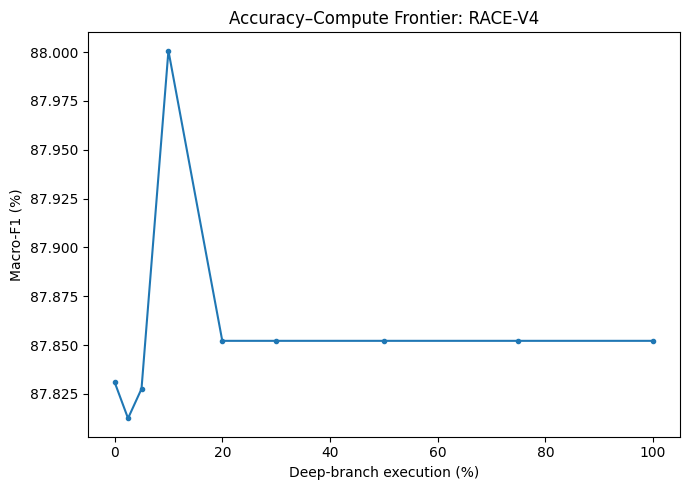

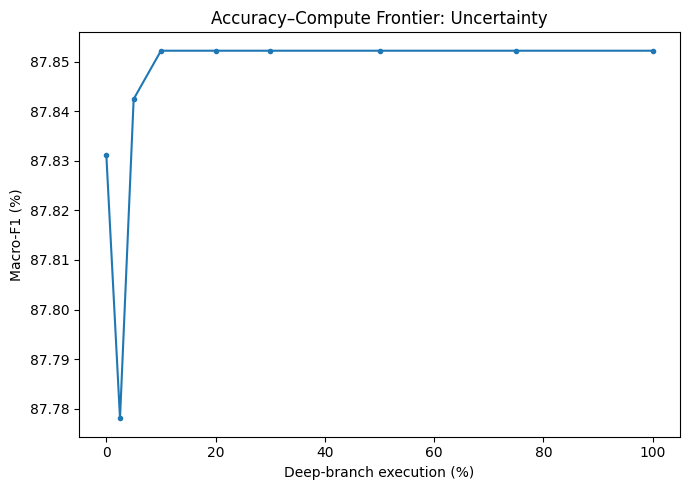

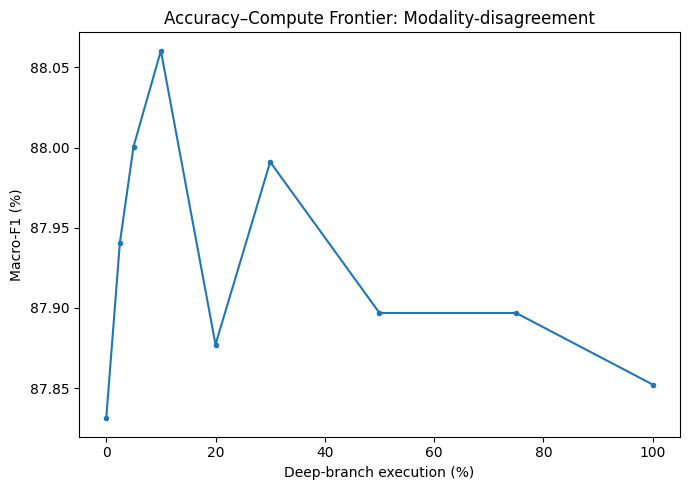

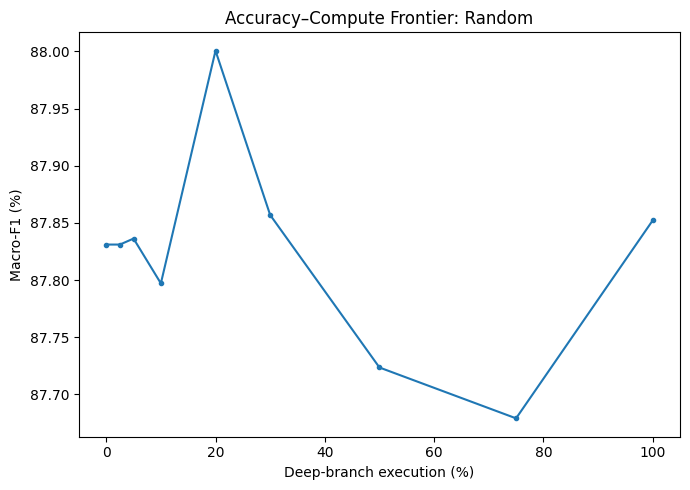

In [14]:
methods=["RACE-V4","Uncertainty","Modality-disagreement","Random"]

for method in methods:
    g=summary[summary.method==method].sort_values("budget")
    plt.figure(figsize=(7,5))
    plt.plot(
        g["deep_rate_mean"]*100,
        g["macro_f1_mean"]*100,
        marker="."
    )
    plt.xlabel("Deep-branch execution (%)")
    plt.ylabel("Macro-F1 (%)")
    plt.title(f"Accuracy–Compute Frontier: {method}")
    plt.tight_layout()
    plt.savefig(
        OUT_DIR/f"pareto_{method.lower().replace('-','_')}.png",
        dpi=180
    )
    plt.show()


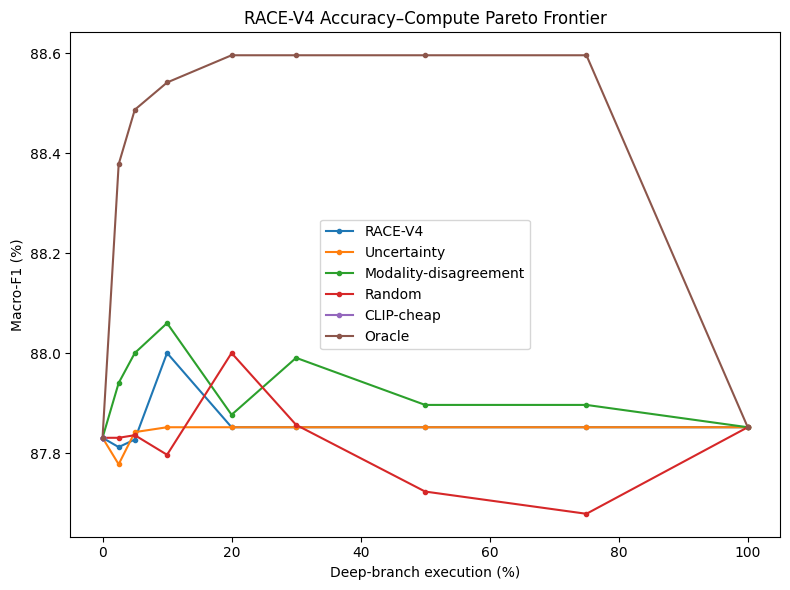

In [15]:
# Combined frontier including the analysis-only Oracle upper bound.
plot_methods=["RACE-V4","Uncertainty","Modality-disagreement","Random","CLIP-cheap","Oracle"]

plt.figure(figsize=(8,6))
for method in plot_methods:
    g=summary[summary.method==method].sort_values("budget")
    x=g["deep_rate_mean"]*100
    y=g["macro_f1_mean"]*100
    plt.plot(x,y,marker=".",label=method)

plt.xlabel("Deep-branch execution (%)")
plt.ylabel("Macro-F1 (%)")
plt.title("RACE-V4 Accuracy–Compute Pareto Frontier")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/"v4_combined_pareto.png",dpi=200)
plt.show()


## Statistical test at matched budgets

The key comparisons are paired on the same test samples and the same deep
predictions:

- RACE-V4 vs CLIP-cheap
- RACE-V4 vs uncertainty routing
- RACE-V4 vs modality-disagreement routing
- RACE-V4 vs random routing

The Oracle is excluded from inferential claims because it uses test labels.
If a bootstrap interval crosses zero, the notebook does not claim superiority.


In [16]:
# Fix: f1_score_macro was referenced in paired_bootstrap_table() below
# but was never defined anywhere in the notebook, causing:
#   NameError: name 'f1_score_macro' is not defined
# Define it as a thin wrapper around the already-imported sklearn f1_score,
# matching the macro-F1 computation used elsewhere (e.g. metric_dict).
def f1_score_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


In [17]:
def paired_bootstrap_table_v4(run, budgets=BUDGETS):
    y=run["arrays"]["y"]
    cheap=run["arrays"]["cheap"]
    deep=run["arrays"]["deep"]
    score=run["arrays"]["race_score"]
    uncertainty=run["arrays"]["uncertainty_score"]
    disagreement=run["arrays"]["disagreement_score"]

    out=[]
    for budget in budgets:
        race_route=exact_k_route(score,budget)
        race=route_logits(cheap,deep,race_route).argmax(1)

        base_specs=[
            ("CLIP-cheap", np.zeros(len(y),dtype=bool)),
            ("Uncertainty", exact_k_route(uncertainty,budget)),
            ("Modality-disagreement", exact_k_route(disagreement,budget))
        ]
        for base_name,base_route in base_specs:
            base=(
                cheap.argmax(1) if base_name=="CLIP-cheap"
                else route_logits(cheap,deep,base_route).argmax(1)
            )
            lo,med,hi=bootstrap_diff(
                y,race,base,f1_score_macro,
                N_BOOT,seed=9000+int(budget*1000)
            )
            out.append({
                "seed":run["seed"],
                "budget":budget,
                "comparison":f"RACE-V4 - {base_name}",
                "ci_low":lo,
                "median_diff":med,
                "ci_high":hi
            })
    return pd.DataFrame(out)

bootstrap_all=pd.concat(
    [paired_bootstrap_table_v4(r) for r in runs],
    ignore_index=True
)
display(bootstrap_all)
bootstrap_all.to_csv(OUT_DIR/"v4_paired_bootstrap_95ci.csv",index=False)

bootstrap_summary=bootstrap_all.groupby(
    ["budget","comparison"]
).agg(
    ci_low_mean=("ci_low","mean"),
    median_diff_mean=("median_diff","mean"),
    ci_high_mean=("ci_high","mean"),
    seeds=("seed","nunique")
).reset_index()

display(bootstrap_summary)
bootstrap_summary.to_csv(
    OUT_DIR/"v4_paired_bootstrap_summary.csv",index=False
)


,seed,budget,comparison,ci_low,median_diff,ci_high
0,13,0.000,RACE-V4 - CLIP-cheap,0.000000,0.000000,0.000000
1,13,0.000,RACE-V4 - Uncertainty,0.000000,0.000000,0.000000
2,13,0.000,RACE-V4 - Modality-disagreement,0.000000,0.000000,0.000000
3,13,0.025,RACE-V4 - CLIP-cheap,-0.003327,-0.000233,0.003057
4,13,0.025,RACE-V4 - Uncertainty,-0.003337,0.000295,0.003687
5,13,0.025,RACE-V4 - Modality-disagreement,-0.004961,-0.001273,0.001840
6,13,0.050,RACE-V4 - CLIP-cheap,-0.004692,0.000263,0.004182
7,13,0.050,RACE-V4 - Uncertainty,-0.002913,-0.000168,0.002494
8,13,0.050,RACE-V4 - Modality-disagreement,-0.006671,-0.001470,0.002545
9,13,0.100,RACE-V4 - CLIP-cheap,-0.003508,0.001500,0.006832


,budget,comparison,ci_low_mean,median_diff_mean,ci_high_mean,seeds
0,0.000,RACE-V4 - CLIP-cheap,0.000000,0.000000,0.000000,1
1,0.000,RACE-V4 - Modality-disagreement,0.000000,0.000000,0.000000,1
2,0.000,RACE-V4 - Uncertainty,0.000000,0.000000,0.000000,1
3,0.025,RACE-V4 - CLIP-cheap,-0.003327,-0.000233,0.003057,1
4,0.025,RACE-V4 - Modality-disagreement,-0.004961,-0.001273,0.001840,1
5,0.025,RACE-V4 - Uncertainty,-0.003337,0.000295,0.003687,1
6,0.050,RACE-V4 - CLIP-cheap,-0.004692,0.000263,0.004182,1
7,0.050,RACE-V4 - Modality-disagreement,-0.006671,-0.001470,0.002545,1
8,0.050,RACE-V4 - Uncertainty,-0.002913,-0.000168,0.002494,1
9,0.100,RACE-V4 - CLIP-cheap,-0.003508,0.001500,0.006832,1


## Resource accounting

Effective expected latency is:

`cheap_cost + deep_rate × extra_deep_cost`

We report latency, throughput, deep execution rate, and relative savings.


In [18]:
test_clip_ms=float(
    resource_components[
        (resource_components.split=="test")&
        (resource_components.component=="CLIP")
    ].ms_per_sample.iloc[0]
)
test_vilt_ms=float(
    resource_components[
        (resource_components.split=="test")&
        (resource_components.component=="ViLT")
    ].ms_per_sample.iloc[0]
)

resource_budget=[]
for budget in BUDGETS:
    effective=test_clip_ms+budget*test_vilt_ms
    savings=1-effective/(test_clip_ms+test_vilt_ms)
    resource_budget.append({
        "budget":budget,
        "deep_rate":budget,
        "clip_ms_per_sample":test_clip_ms,
        "vilt_ms_per_sample":test_vilt_ms,
        "effective_ms_per_sample":effective,
        "throughput_samples_per_sec":1000/effective,
        "latency_savings_vs_always_deep":savings
    })

resource_budget=pd.DataFrame(resource_budget)
display(resource_budget)
resource_budget.to_csv(OUT_DIR/"v4_resource_budget_curve.csv",index=False)

# Merge compute with predictive performance.
resource_results=summary.merge(
    resource_budget[["budget","effective_ms_per_sample","throughput_samples_per_sec",
                     "latency_savings_vs_always_deep"]],
    on="budget",
    how="left"
)
resource_results.to_csv(OUT_DIR/"v4_results_with_compute.csv",index=False)
display(resource_results)


,budget,deep_rate,clip_ms_per_sample,vilt_ms_per_sample,effective_ms_per_sample,throughput_samples_per_sec,latency_savings_vs_always_deep
0,0.000,0.000,11.766593,21.140355,11.766593,84.986369,0.642428
1,0.025,0.025,11.766593,21.140355,12.295102,81.333202,0.626368
2,0.050,0.050,11.766593,21.140355,12.823611,77.981157,0.610307
3,0.100,0.100,11.766593,21.140355,13.880628,72.042848,0.578185
4,0.200,0.200,11.766593,21.140355,15.994664,62.520851,0.513943
5,0.300,0.300,11.766593,21.140355,18.108699,55.222077,0.449700
6,0.500,0.500,11.766593,21.140355,22.336770,44.769229,0.321214
7,0.750,0.750,11.766593,21.140355,27.621859,36.203211,0.160607
8,1.000,1.000,11.766593,21.140355,32.906948,30.388719,0.000000


,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean,effective_ms_per_sample,throughput_samples_per_sec,latency_savings_vs_always_deep
0,0.0,Always-deep,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0,11.766593,84.986369,0.642428
1,0.0,CLIP-cheap,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0,11.766593,84.986369,0.642428
2,0.0,Modality-disagreement,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0,11.766593,84.986369,0.642428
3,0.0,Oracle,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0,11.766593,84.986369,0.642428
4,0.0,RACE-V4,0.8835,NaN,0.878311,NaN,0.274853,0.166557,0.0,11.766593,84.986369,0.642428
...,...,...,...,...,...,...,...,...,...,...,...,...
58,1.0,Modality-disagreement,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0,32.906948,30.388719,0.000000
59,1.0,Oracle,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0,32.906948,30.388719,0.000000
60,1.0,RACE-V4,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0,32.906948,30.388719,0.000000
61,1.0,Random,0.8830,NaN,0.878522,NaN,0.292763,0.172269,1.0,32.906948,30.388719,0.000000


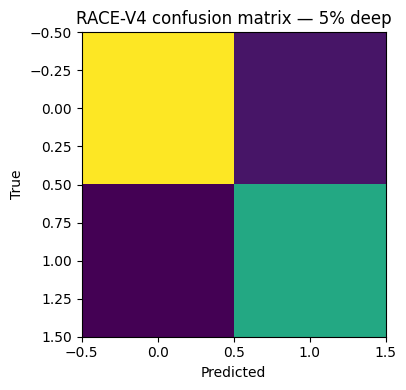

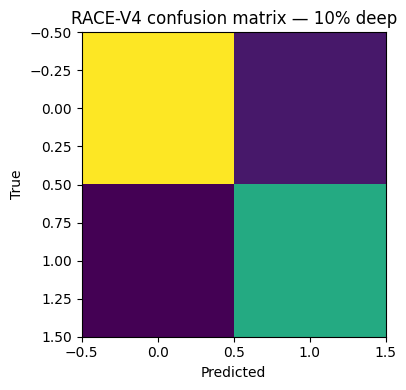

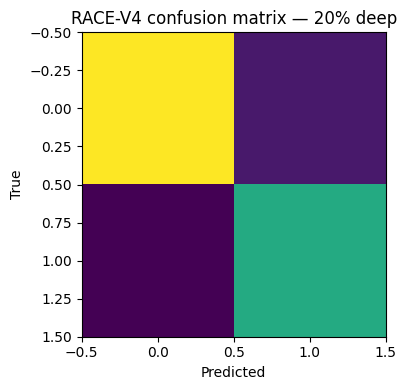

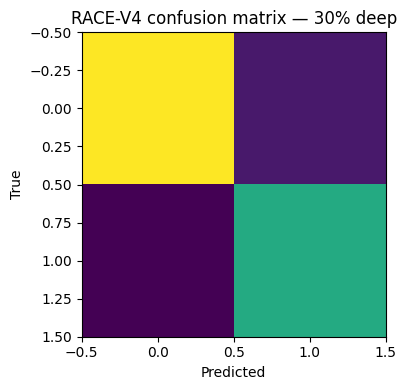

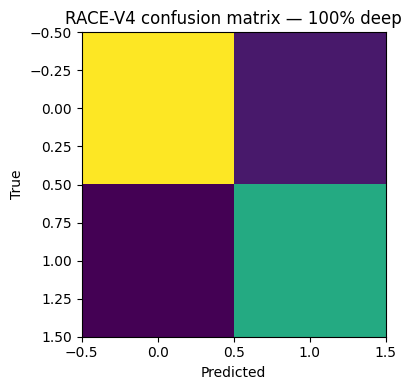

In [19]:
# Confusion matrices for representative RACE-V4 budgets, first seed.
rep=runs[0]
y=rep["arrays"]["y"]
cheap=rep["arrays"]["cheap"]
deep=rep["arrays"]["deep"]
score=rep["arrays"]["race_score"]

for budget in [0.05,0.10,0.20,0.30,1.0]:
    route=exact_k_route(score,budget)
    pred=route_logits(cheap,deep,route).argmax(1)
    cm=confusion_matrix(y,pred)
    pd.DataFrame(cm).to_csv(
        OUT_DIR/f"v4_confusion_matrix_race_{int(budget*100)}pct.csv",
        index=False
    )
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"RACE-V4 confusion matrix — {int(budget*100)}% deep")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(
        OUT_DIR/f"v4_confusion_matrix_race_{int(budget*100)}pct.png",
        dpi=180
    )
    plt.show()


In [20]:
# Parameter counts.
def param_counts(model):
    return {
        "total":sum(p.numel() for p in model.parameters()),
        "trainable":sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

rep=runs[0]
params=pd.DataFrame([
    {"component":"CLIP backbone",**param_counts(clip_model)},
    {"component":"ViLT backbone",**param_counts(vilt_model)},
    {"component":"Cheap head",**param_counts(rep["cheap"])},
    {"component":"Deep residual head",**param_counts(rep["deep"])},
    {"component":"Text head",**param_counts(rep["text_head"])},
    {"component":"Image head",**param_counts(rep["image_head"])}
])
display(params)
params.to_csv(OUT_DIR/"v4_parameter_counts.csv",index=False)


,component,total,trainable
0,CLIP backbone,151277313,0
1,ViLT backbone,111595008,0
2,Cheap head,558466,558466
3,Deep residual head,1118466,1118466
4,Text head,164994,164994
5,Image head,164994,164994


# Decision gate

V4/RACE is a successful method experiment only if, across multiple seeds:

1. the risk model is meaningfully calibrated and its top-ranked samples have
   higher observed cheap-model error rates than lower-ranked samples;
2. RACE-V4 is competitive with or better than uncertainty and
   modality-disagreement routing at matched budgets over a meaningful region;
3. the advantage is not a single-seed artifact;
4. the compute savings are substantial and measured at the same hardware;
5. the Oracle shows that there is still useful headroom for selective escalation.

The Oracle is analysis-only and must never be described as a deployable competitor.

If these gates fail, do not manufacture a novelty claim. The notebook is
designed to make that failure explicit.


## Risk-ranking quality

The central V4 diagnostic is different from V4:

> Do high predicted-risk samples actually contain a higher concentration of
> cheap-model errors?

We also report realized deep-branch gain for diagnostic purposes. This is
computed on the test set only after routing and is never used to train or
select the policy.


,fraction,mean_predicted_risk,observed_error_rate,mean_actual_deep_gain,positive_deep_gain_fraction
0,0.010,0.922213,0.4000,-0.059219,0.450000
1,0.025,0.909816,0.4800,-0.013647,0.500000
2,0.050,0.895968,0.4600,-0.004312,0.530000
3,0.100,0.868791,0.4500,-0.014497,0.535000
4,0.200,0.804258,0.3950,-0.037389,0.560000
5,0.300,0.726970,0.3100,-0.031532,0.643333
6,0.500,0.574155,0.2200,-0.027282,0.732000
7,1.000,0.340389,0.1165,-0.017910,0.857000


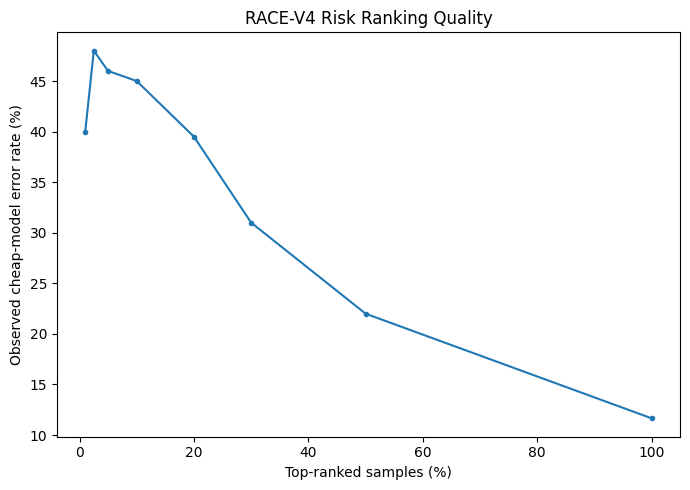

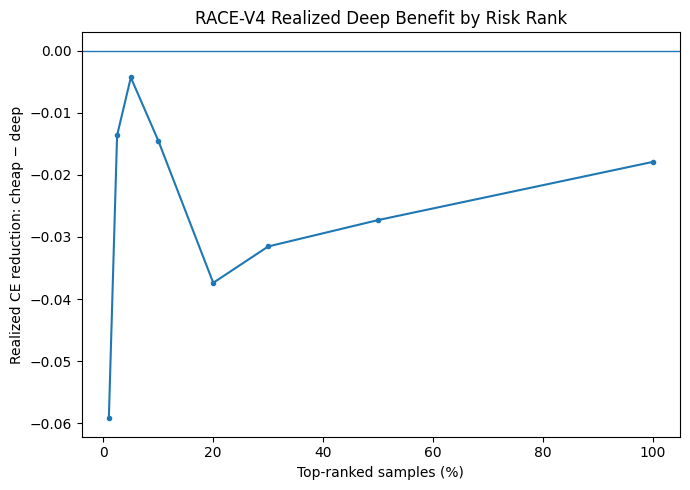

In [21]:
risk_summary=topk_risk_all.groupby("fraction").agg(
    mean_predicted_risk=("mean_predicted_risk","mean"),
    observed_error_rate=("observed_error_rate","mean"),
    mean_actual_deep_gain=("mean_actual_deep_gain","mean"),
    positive_deep_gain_fraction=("positive_deep_gain_fraction","mean")
).reset_index()

display(risk_summary)
risk_summary.to_csv(OUT_DIR/"v4_topk_risk_summary.csv",index=False)

plt.figure(figsize=(7,5))
plt.plot(
    risk_summary["fraction"]*100,
    risk_summary["observed_error_rate"]*100,
    marker="."
)
plt.xlabel("Top-ranked samples (%)")
plt.ylabel("Observed cheap-model error rate (%)")
plt.title("RACE-V4 Risk Ranking Quality")
plt.tight_layout()
plt.savefig(OUT_DIR/"v4_risk_ranking.png",dpi=200)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    risk_summary["fraction"]*100,
    risk_summary["mean_actual_deep_gain"],
    marker="."
)
plt.axhline(0,linewidth=1)
plt.xlabel("Top-ranked samples (%)")
plt.ylabel("Realized CE reduction: cheap − deep")
plt.title("RACE-V4 Realized Deep Benefit by Risk Rank")
plt.tight_layout()
plt.savefig(OUT_DIR/"v4_risk_gain_by_rank.png",dpi=200)
plt.show()


## V4 paper-ready outputs

- `v4_all_seed_budget_metrics.csv`
- `v4_manuscript_summary_mean_sd.csv`
- `v4_matched_budget_comparison.csv`
- `v4_paired_bootstrap_95ci.csv`
- `v4_paired_bootstrap_summary.csv`
- `v4_risk_diagnostics.csv`
- `v4_topk_risk.csv`
- `v4_topk_risk_summary.csv`
- `v4_oracle_upper_bound.csv`
- `v4_resource_budget_curve.csv`
- `v4_results_with_compute.csv`
- `v4_test_predictions.csv`
- `v4_parameter_counts.csv`
- `v4_combined_pareto.png`
- `v4_risk_ranking.png`
- `v4_risk_gain_by_rank.png`

### Recommended interpretation

Do not report V4 as a successful contribution unless the multi-seed results
support the decision gate above. The notebook intentionally separates
training, calibration, validation-based budget selection, and final test
analysis.
